<a href="https://colab.research.google.com/github/HinaH1/dental-caries-segmentation/blob/main/experiments/01_object_detection_initialtrial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 1: Baseline Object Detection for Dental Caries Using YOLOv8

## Objective
To evaluate the feasibility of bounding-box based object detection for identifying dental caries in periapical radiographs.

---

## Rationale

Object detection was selected as the initial approach due to:

- Simpler annotation requirements (bounding boxes)
- Faster training time compared to segmentation
- Established performance of YOLO models in detection tasks

This experiment serves as a baseline comparison before exploring instance segmentation.

---

## Methodology

- Dataset imported from Kaggle
- Restoration class removed to isolate caries
- YOLOv8 object detection model trained
- Performance evaluated using:
  - mAP50
  - Precision
  - Recall

---

## Observations

- Bounding boxes struggled to accurately capture irregular lesion boundaries.
- Caries often appear with diffuse or non-rectangular shapes.
- Limited dataset size affected generalisation performance.

---

## Conclusion

While object detection demonstrated initial feasibility, it was deemed insufficient for precise lesion localisation.

Instance segmentation was therefore selected as the primary modelling approach for subsequent experiments.

In [ ]:
!nvidia-smi
!pip -q install ultralytics opencv-python pillow tqdm pyyaml scikit-learn

Mon Mar  2 13:23:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q kaggle

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'HinaH1'
os.environ['KAGGLE_KEY'] = 'KGAT_7592a2cc2479efda42b2d4080de34e3f'

In [ ]:
!pip -q install kaggle
!mkdir -p /content/cavity_data
!kaggle datasets download -d alokkumar175358/dental-cavity-radiograph-images -p /content/cavity_data --unzip
!ls -la /content/cavity_data

Dataset URL: https://www.kaggle.com/datasets/alokkumar175358/dental-cavity-radiograph-images
License(s): MIT
  0% 0.00/13.2M [00:00<?, ?B/s]
100% 13.2M/13.2M [00:00<00:00, 1.03GB/s]
total 32
drwxr-xr-x 5 root root 4096 Mar  2 13:23 .
drwxr-xr-x 1 root root 4096 Mar  2 13:23 ..
-rw-r--r-- 1 root root  263 Mar  2 13:23 data.yaml
-rw-r--r-- 1 root root  145 Mar  2 13:23 README.dataset.txt
-rw-r--r-- 1 root root 1073 Mar  2 13:23 README.roboflow.txt
drwxr-xr-x 4 root root 4096 Mar  2 13:23 test
drwxr-xr-x 4 root root 4096 Mar  2 13:23 train
drwxr-xr-x 4 root root 4096 Mar  2 13:23 valid


In [ ]:
!find /content/cavity_data -maxdepth 4 -type d -print
!find /content/cavity_data -maxdepth 4 -type f -name "*.yaml" -o -name "*.yml"

/content/cavity_data
/content/cavity_data/train
/content/cavity_data/train/labels
/content/cavity_data/train/images
/content/cavity_data/valid
/content/cavity_data/valid/labels
/content/cavity_data/valid/images
/content/cavity_data/test
/content/cavity_data/test/labels
/content/cavity_data/test/images
/content/cavity_data/data.yaml


In [ ]:
!cat /content/cavity_data/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['Cavity']

roboflow:
  workspace: infotsav
  project: dental-images-mvmez
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/infotsav/dental-images-mvmez/dataset/3

In [ ]:
%cd /content/cavity_data
!yolo detect train data=data.yaml model=yolov8n.pt imgsz=640 epochs=50 batch=16

/content/cavity_data
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, i

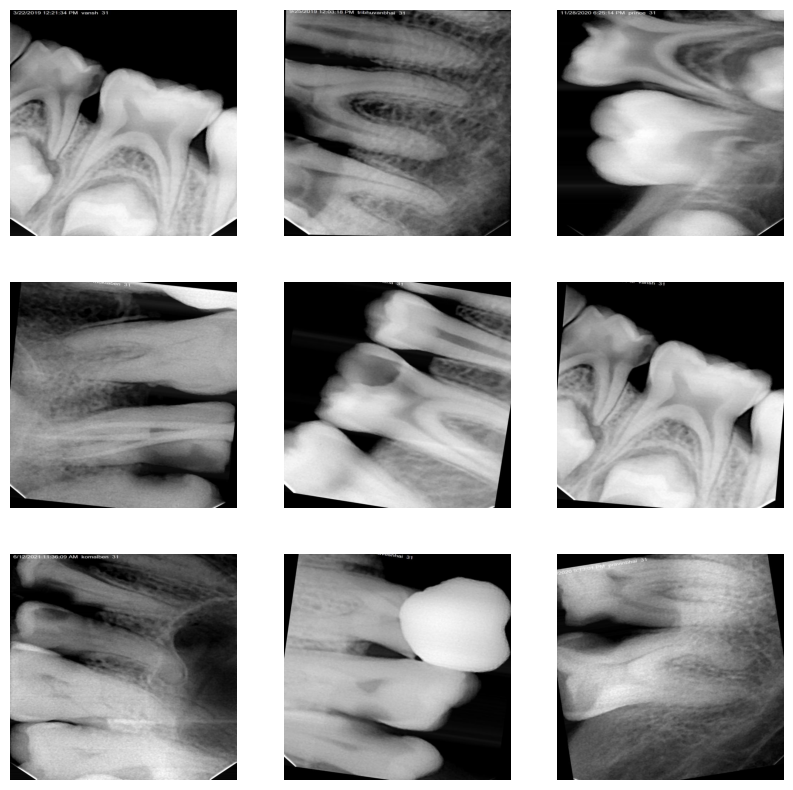

In [ ]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_dir = Path("/content/cavity_data/train/images")
imgs = random.sample(list(img_dir.glob("*.jpg")), 9)

plt.figure(figsize=(10,10))
for i,p in enumerate(imgs,1):
    plt.subplot(3,3,i)
    plt.imshow(mpimg.imread(p), cmap="gray")
    plt.axis("off")
plt.show()

## Reflection

This experiment informed the architectural decision to move from bounding-box detection to pixel-level segmentation.

The transition reflects the importance of modelling lesion morphology in medical imaging tasks.

In [ ]:
import getpass, os
token = getpass.getpass("Paste your GitHub token (it will be hidden): ")
os.environ["GITHUB_TOKEN"] = token

Paste your GitHub token (it will be hidden): ··········


In [ ]:
!git clone https://$GITHUB_TOKEN@github.com/HinaH1/dental-caries-segmentation.git

Cloning into 'dental-caries-segmentation'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 22 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 9.81 KiB | 9.81 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [ ]:
!git config --global user.name "HinaH1"
!git config --global user.email "sc22hh@leeds.ac.uk"

In [ ]:
%cd /content/dental-caries-segmentation
!pwd
!ls

/content/dental-caries-segmentation
/content/dental-caries-segmentation
experiments  LICENSE  notebooks  README.md  requirements.txt


In [ ]:
!ls

01_object_detection_baseline.ipynb  experiment_log.md


In [ ]:
!rm 01_object_detection_baseline.ipynb

In [ ]:
!ls

experiment_log.md


In [ ]:
!git add /content/dental-caries-segmentation/experiments/01_object_detection_baseline.ipynb
!git commit -m "Add initial experiment object detection experiment notebook"
!git push

[main 54d439d] Add initial experiment object detection experiment notebook
 1 file changed, 1 deletion(-)
 delete mode 100644 experiments/01_object_detection_baseline.ipynb
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (2/2), done.
Writing objects: 100% (3/3), 329 bytes | 329.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/HinaH1/dental-caries-segmentation.git
   8fc265b..54d439d  main -> main
